In [1]:
import importlib

In [2]:
import sys
sys.path.append("../src/meta-estimators")

In [24]:
import pandas as pd
import gprofiler

gp = gprofiler.GProfiler(return_dataframe=True)
df = pd.read_csv("https://raw.githubusercontent.com/Asthayadav09/airway-RNA-Seq-Dataset/main/airway_DESeq2_results.csv", index_col=0)
df["symbol"] = gp.convert(df.index.tolist())["name"].tolist()
df = df[df.symbol.ne("None")].dropna()

In [26]:
df = df.dropna().set_index("symbol")
df = df.reset_index().drop_duplicates(subset=["symbol"]).set_index("symbol")

KeyError: "None of ['symbol'] are in the columns"

In [27]:
from enrichr import GeneOntologyLibraries
go_terms = GeneOntologyLibraries().pull_assignment_matrix("GO_Biological_Process_2025")

In [ ]:
import ipf
import importlib
importlib.reload(ipf)
from ipf import ReweightingPreparer, IterativeProportionalFitting

deseq_results, go_terms, row_marginals, column_marginals = ReweightingPreparer.clean(go_terms, df)
balanced_matrix = IterativeProportionalFitting().degree_corrected_doubly_stochastic(
    A=go_terms, 
)

In [ ]:
balanced_matrix

<Axes: xlabel='metaLFC', ylabel='log10padj'>

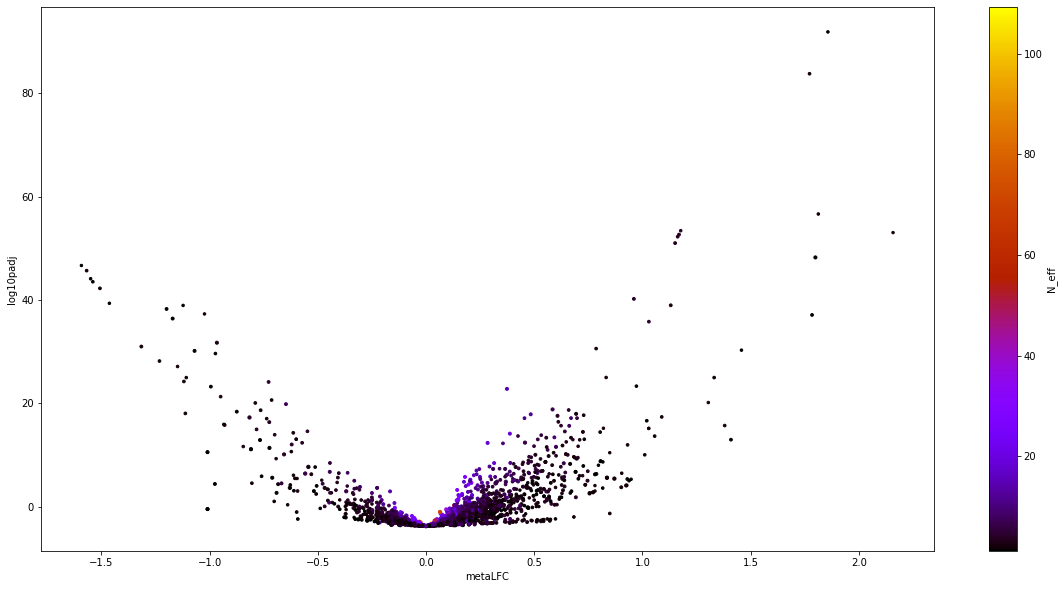

In [30]:
import numpy as np
from meta import GeneOntologyDifferentialResults

gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)

gene_ontology_results["log_weight"] = np.log1p(gene_ontology_results["weight"])

gene_ontology_results.query("top1_contribution < 0.9") \
    .plot.scatter(x="metaLFC", y="log10padj", c="N_eff", s="log_weight", figsize=(20, 10), cmap="gnuplot")

<Axes: xlabel='N_eff', ylabel='metaLFC'>

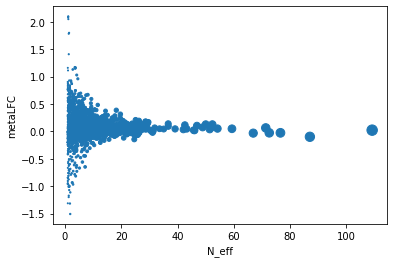

In [31]:
gene_ontology_results.eval("ratio = N_eff / n_terms").query("n_terms > 10").plot.scatter(x="N_eff", y="metaLFC", s="N_eff")

In [38]:
import matplotlib.pyplot as plt

gene_ontology_results.query("padj < 0.001 and N_eff > 1.5").sort_values(by="metaLFC")

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff,log_weight
Induction of Positive Chemotaxis (GO:0050930),10,-1.568378,0.105345,-1.774854,-1.361903,1292.310281,3.941361e-50,2.101928e-46,49.404354,45.677382,0.764132,0.969671,1.674921,7.164960
Positive Regulation of Positive Chemotaxis (GO:0050927),13,-1.507069,0.105013,-1.712893,-1.301244,1680.003365,1.045347e-46,5.574836e-43,45.980739,42.253768,0.722910,0.940596,1.865468,7.427146
Chemokine-Mediated Signaling Pathway (GO:0070098),22,-1.315658,0.105876,-1.523175,-1.108141,2843.082618,1.878596e-35,1.001855e-31,34.726167,30.999195,0.746524,0.917283,1.764450,7.952996
Lymphocyte Chemotaxis (GO:0048247),9,-1.231907,0.103531,-1.434828,-1.028987,1163.079253,1.198551e-32,6.391875e-29,31.921343,28.194372,0.731474,0.987527,1.796731,7.059686
Regulation of Leukocyte Tethering or Rolling (GO:1903236),6,-1.148233,0.098186,-1.340678,-0.955788,775.386169,1.360818e-31,7.257244e-28,30.866200,27.139228,0.691042,0.996199,1.904115,6.654650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Positive Regulation of Vascular Permeability (GO:0043117),10,1.331400,0.118163,1.099800,1.563000,1292.310281,1.899557e-29,1.013034e-25,28.721348,24.994376,0.760984,0.980776,1.647056,7.164960
Male Gamete Generation (GO:0048232),9,1.380237,0.150033,1.086171,1.674302,1163.079253,3.594971e-20,1.917198e-16,19.444305,15.717333,0.632910,0.972550,2.270030,7.059686
Copper Ion Transport (GO:0006825),9,1.772171,0.089004,1.597724,1.946618,1163.079253,3.252538e-88,1.734579e-84,87.487778,83.760806,0.764318,0.967252,1.662753,7.059686
Neurotrophin TRK Receptor Signaling Pathway (GO:0048011),5,1.812789,0.109938,1.597311,2.028268,646.155140,4.385353e-61,2.338709e-57,60.357995,56.631024,0.760033,1.000000,1.679611,6.472586


/Users/jameshaberberger/GitHub/meta-estimators/notebook/../src/meta-estimators/plotting.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


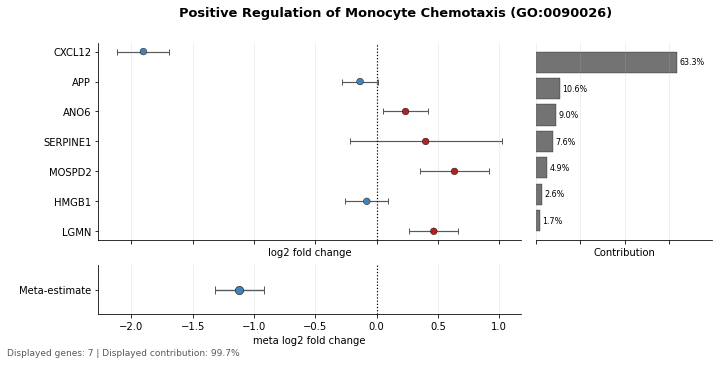

In [36]:
from plotting import ForestPlotter

term = "Positive Regulation of Monocyte Chemotaxis (GO:0090026)"
output = ForestPlotter(deseq_results, balanced_matrix, gene_ontology_results).plot_term(term, cutoff=0.999)